使用KAN数据进行LSTM

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from kan.utils import create_dataset

# 检查是否有GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [2]:
# 1. 创建数据集
def f(x): return torch.exp(torch.sin(torch.pi*x[:, [0]]) + x[:, [1]]**2)


# 创建数据集
dataset = create_dataset(f, n_var=2, device=device)
print(f"训练输入形状: {dataset['train_input'].shape}")
print(f"训练标签形状: {dataset['train_label'].shape}")

训练输入形状: torch.Size([1000, 2])
训练标签形状: torch.Size([1000, 1])


In [3]:
# 2. 数据预处理
# 将数据移到CPU进行预处理（如果需要）
train_input = dataset['train_input'].cpu().numpy()
train_label = dataset['train_label'].cpu().numpy()
test_input = dataset['test_input'].cpu().numpy()
test_label = dataset['test_label'].cpu().numpy()

# 标准化
input_scaler = StandardScaler()
label_scaler = StandardScaler()

train_input_scaled = input_scaler.fit_transform(train_input)
train_label_scaled = label_scaler.fit_transform(train_label)
test_input_scaled = input_scaler.transform(test_input)
test_label_scaled = label_scaler.transform(test_label)

In [4]:
# LSTM期望的形状: (batch_size, sequence_length, features)
# 我们将2个特征视为2个时间步的特征序列


def reshape_for_lstm(X, sequence_length=1):
    """将特征重塑为序列格式"""
    # 如果sequence_length=1，每个样本只有一个时间步
    return X.reshape(-1, sequence_length, X.shape[1])

In [5]:
# 3. 为LSTM重塑数据格式

SEQ_LENGTH = 1  # 每个样本的"时间步"数
n_features = 2  # 每个时间步的特征数

train_input_reshaped = reshape_for_lstm(train_input_scaled, SEQ_LENGTH)
test_input_reshaped = reshape_for_lstm(test_input_scaled, SEQ_LENGTH)

print(f"重塑后的训练输入形状: {train_input_reshaped.shape}")
print(f"重塑后的测试输入形状: {test_input_reshaped.shape}")

# 转换为PyTorch张量
X_train = torch.FloatTensor(train_input_reshaped).to(device)
y_train = torch.FloatTensor(train_label_scaled).to(device)
X_test = torch.FloatTensor(test_input_reshaped).to(device)
y_test = torch.FloatTensor(test_label_scaled).to(device)

重塑后的训练输入形状: (1000, 1, 2)
重塑后的测试输入形状: (1000, 1, 2)


In [6]:
# 4. 定义LSTM模型
class LSTMPredictor(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=1, output_size=1):
        super(LSTMPredictor, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # LSTM层
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2 if num_layers > 1 else 0
        )

        # 全连接层
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, output_size)
        )

    def forward(self, x):
        # 初始化隐藏状态
        h0 = torch.zeros(self.num_layers, x.size(
            0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(
            0), self.hidden_size).to(x.device)

        # LSTM前向传播
        lstm_out, _ = self.lstm(x, (h0, c0))

        # 取最后一个时间步的输出
        out = lstm_out[:, -1, :]

        # 全连接层
        out = self.fc(out)
        return out


# 初始化模型
model = LSTMPredictor(
    input_size=n_features,
    hidden_size=64,
    num_layers=2,
    output_size=1
).to(device)


In [7]:
# 5. 定义损失函数和优化器
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=10, factor=0.5)

In [8]:
# 6. 训练模型
def train_model(model, X_train, y_train, X_test, y_test, epochs=200, batch_size=32):
    train_losses = []
    val_losses = []

    # 创建数据加载器
    from torch.utils.data import DataLoader, TensorDataset
    train_dataset = TensorDataset(X_train, y_train)
    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True)

    for epoch in range(epochs):
        model.train()
        train_loss = 0

        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()

            # 前向传播
            predictions = model(batch_x)
            loss = criterion(predictions, batch_y)

            # 反向传播
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item()

        # 验证
        model.eval()
        with torch.no_grad():
            val_predictions = model(X_test)
            val_loss = criterion(val_predictions, y_test)

        avg_train_loss = train_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        val_losses.append(val_loss.item())

        # 学习率调度
        scheduler.step(val_loss)

        if (epoch + 1) % 20 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], '
                  f'Train Loss: {avg_train_loss:.6f}, '
                  f'Val Loss: {val_loss.item():.6f}')

    return train_losses, val_losses


# 训练
print("\n开始训练LSTM模型...")
train_losses, val_losses = train_model(
    model, X_train, y_train, X_test, y_test,
    epochs=200, batch_size=64
)


开始训练LSTM模型...
Epoch [20/200], Train Loss: 0.315692, Val Loss: 0.259889
Epoch [40/200], Train Loss: 0.087536, Val Loss: 0.040723
Epoch [60/200], Train Loss: 0.051214, Val Loss: 0.015105
Epoch [80/200], Train Loss: 0.055836, Val Loss: 0.010810
Epoch [100/200], Train Loss: 0.048887, Val Loss: 0.011718
Epoch [120/200], Train Loss: 0.048014, Val Loss: 0.007376
Epoch [140/200], Train Loss: 0.043774, Val Loss: 0.007652
Epoch [160/200], Train Loss: 0.049568, Val Loss: 0.005485
Epoch [180/200], Train Loss: 0.040366, Val Loss: 0.005737
Epoch [200/200], Train Loss: 0.052636, Val Loss: 0.005535


In [9]:
# 7. 评估模型
model.eval()
with torch.no_grad():
    # 训练集预测
    train_pred_scaled = model(X_train).cpu().numpy()
    test_pred_scaled = model(X_test).cpu().numpy()

    # 反标准化
    train_pred = label_scaler.inverse_transform(train_pred_scaled)
    test_pred = label_scaler.inverse_transform(test_pred_scaled)

    train_true = label_scaler.inverse_transform(y_train.cpu().numpy())
    test_true = label_scaler.inverse_transform(y_test.cpu().numpy())

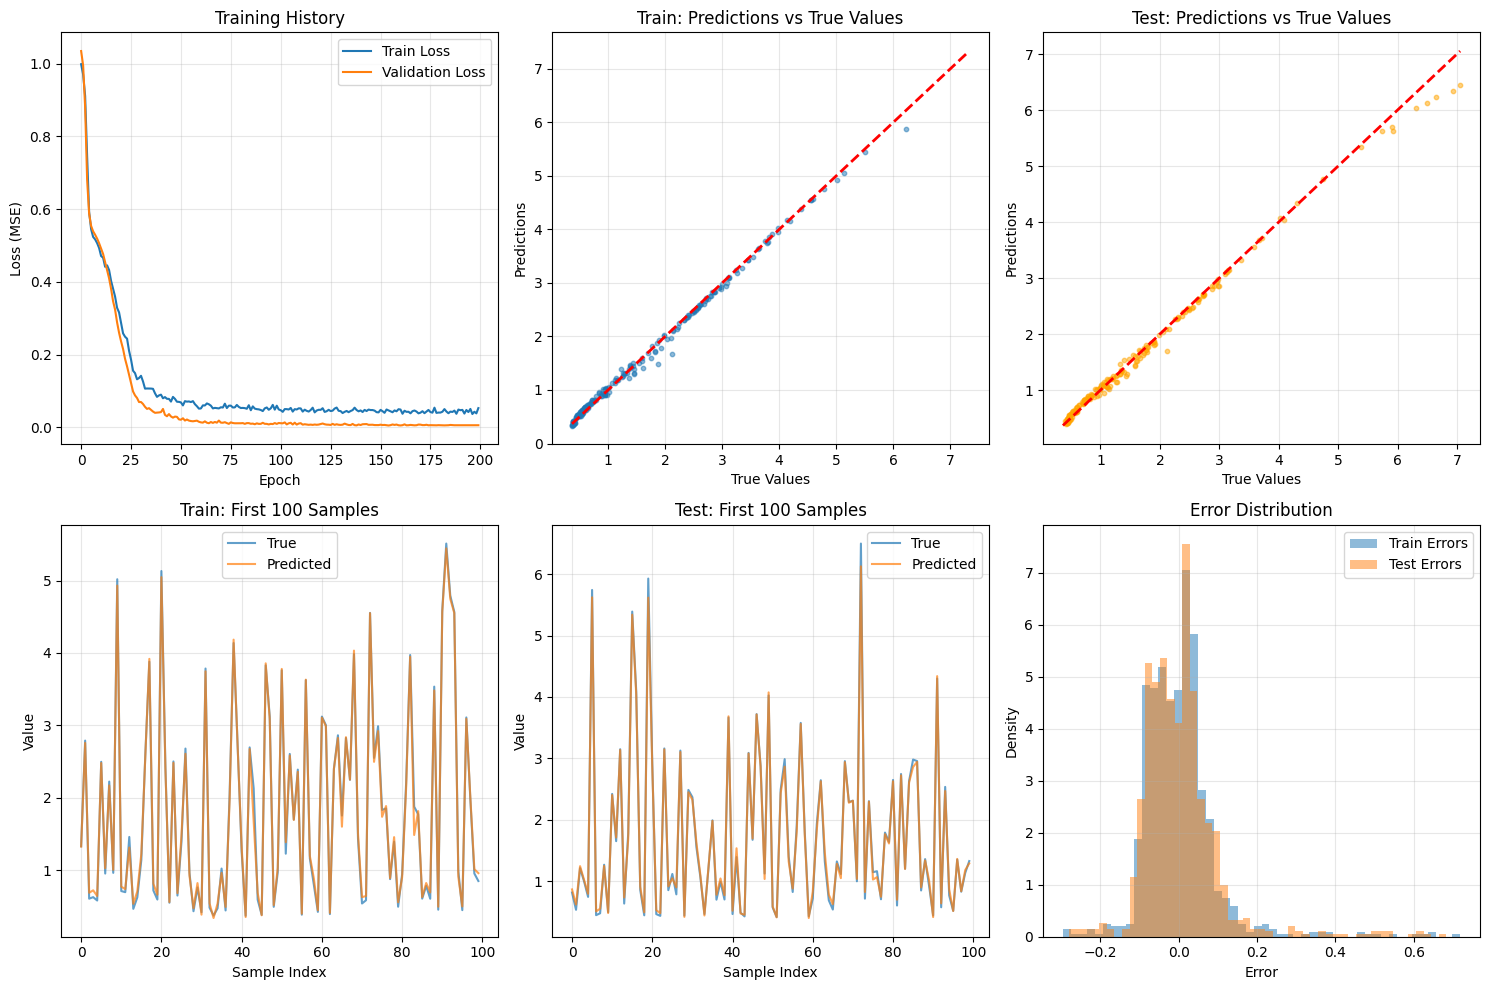

In [10]:
# 8. 可视化结果
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 训练过程
axes[0, 0].plot(train_losses, label='Train Loss')
axes[0, 0].plot(val_losses, label='Validation Loss')
axes[0, 0].set_title('Training History')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss (MSE)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 训练集预测 vs 真实值
axes[0, 1].scatter(train_true[:200], train_pred[:200], alpha=0.5, s=10)
axes[0, 1].plot([train_true.min(), train_true.max()],
                [train_true.min(), train_true.max()],
                'r--', lw=2)
axes[0, 1].set_title('Train: Predictions vs True Values')
axes[0, 1].set_xlabel('True Values')
axes[0, 1].set_ylabel('Predictions')
axes[0, 1].grid(True, alpha=0.3)

# 测试集预测 vs 真实值
axes[0, 2].scatter(test_true[:200], test_pred[:200],
                   alpha=0.5, s=10, color='orange')
axes[0, 2].plot([test_true.min(), test_true.max()],
                [test_true.min(), test_true.max()],
                'r--', lw=2)
axes[0, 2].set_title('Test: Predictions vs True Values')
axes[0, 2].set_xlabel('True Values')
axes[0, 2].set_ylabel('Predictions')
axes[0, 2].grid(True, alpha=0.3)

# 训练集样本对比
axes[1, 0].plot(train_true[:100], label='True', alpha=0.7)
axes[1, 0].plot(train_pred[:100], label='Predicted', alpha=0.7)
axes[1, 0].set_title('Train: First 100 Samples')
axes[1, 0].set_xlabel('Sample Index')
axes[1, 0].set_ylabel('Value')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 测试集样本对比
axes[1, 1].plot(test_true[:100], label='True', alpha=0.7)
axes[1, 1].plot(test_pred[:100], label='Predicted', alpha=0.7)
axes[1, 1].set_title('Test: First 100 Samples')
axes[1, 1].set_xlabel('Sample Index')
axes[1, 1].set_ylabel('Value')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 误差分布
train_errors = train_true.flatten() - train_pred.flatten()
test_errors = test_true.flatten() - test_pred.flatten()

axes[1, 2].hist(train_errors, bins=50, alpha=0.5,
                label='Train Errors', density=True)
axes[1, 2].hist(test_errors, bins=50, alpha=0.5,
                label='Test Errors', density=True)
axes[1, 2].set_title('Error Distribution')
axes[1, 2].set_xlabel('Error')
axes[1, 2].set_ylabel('Density')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()